In [1]:
import pandas as pd

# Load the model dataset
df_model = pd.read_parquet("../output/df_model.parquet")

# Inspect the dataframe structure
print("DataFrame Info:")
print(df_model.info())

# Print summary statistics for numerical features
print("Summary Statistics:")
print(df_model.describe())

DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11229 entries, 0 to 11228
Data columns (total 17 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   Longitude            11229 non-null  float64       
 1   Latitude             11229 non-null  float64       
 2   datetime             11229 non-null  datetime64[ns]
 3   UHI Index            11229 non-null  float64       
 4   building_count       10077 non-null  float64       
 5   mean_height          10077 non-null  float64       
 6   total_area           10077 non-null  float64       
 7   building_area_ratio  10077 non-null  float64       
 8   mean_ndvi            9514 non-null   float64       
 9   median_ndvi          9514 non-null   float64       
 10  std_ndvi             9496 non-null   float64       
 11  mean_lst             11229 non-null  float64       
 12  max_lst              11229 non-null  float64       
 13  mean_air_temp  

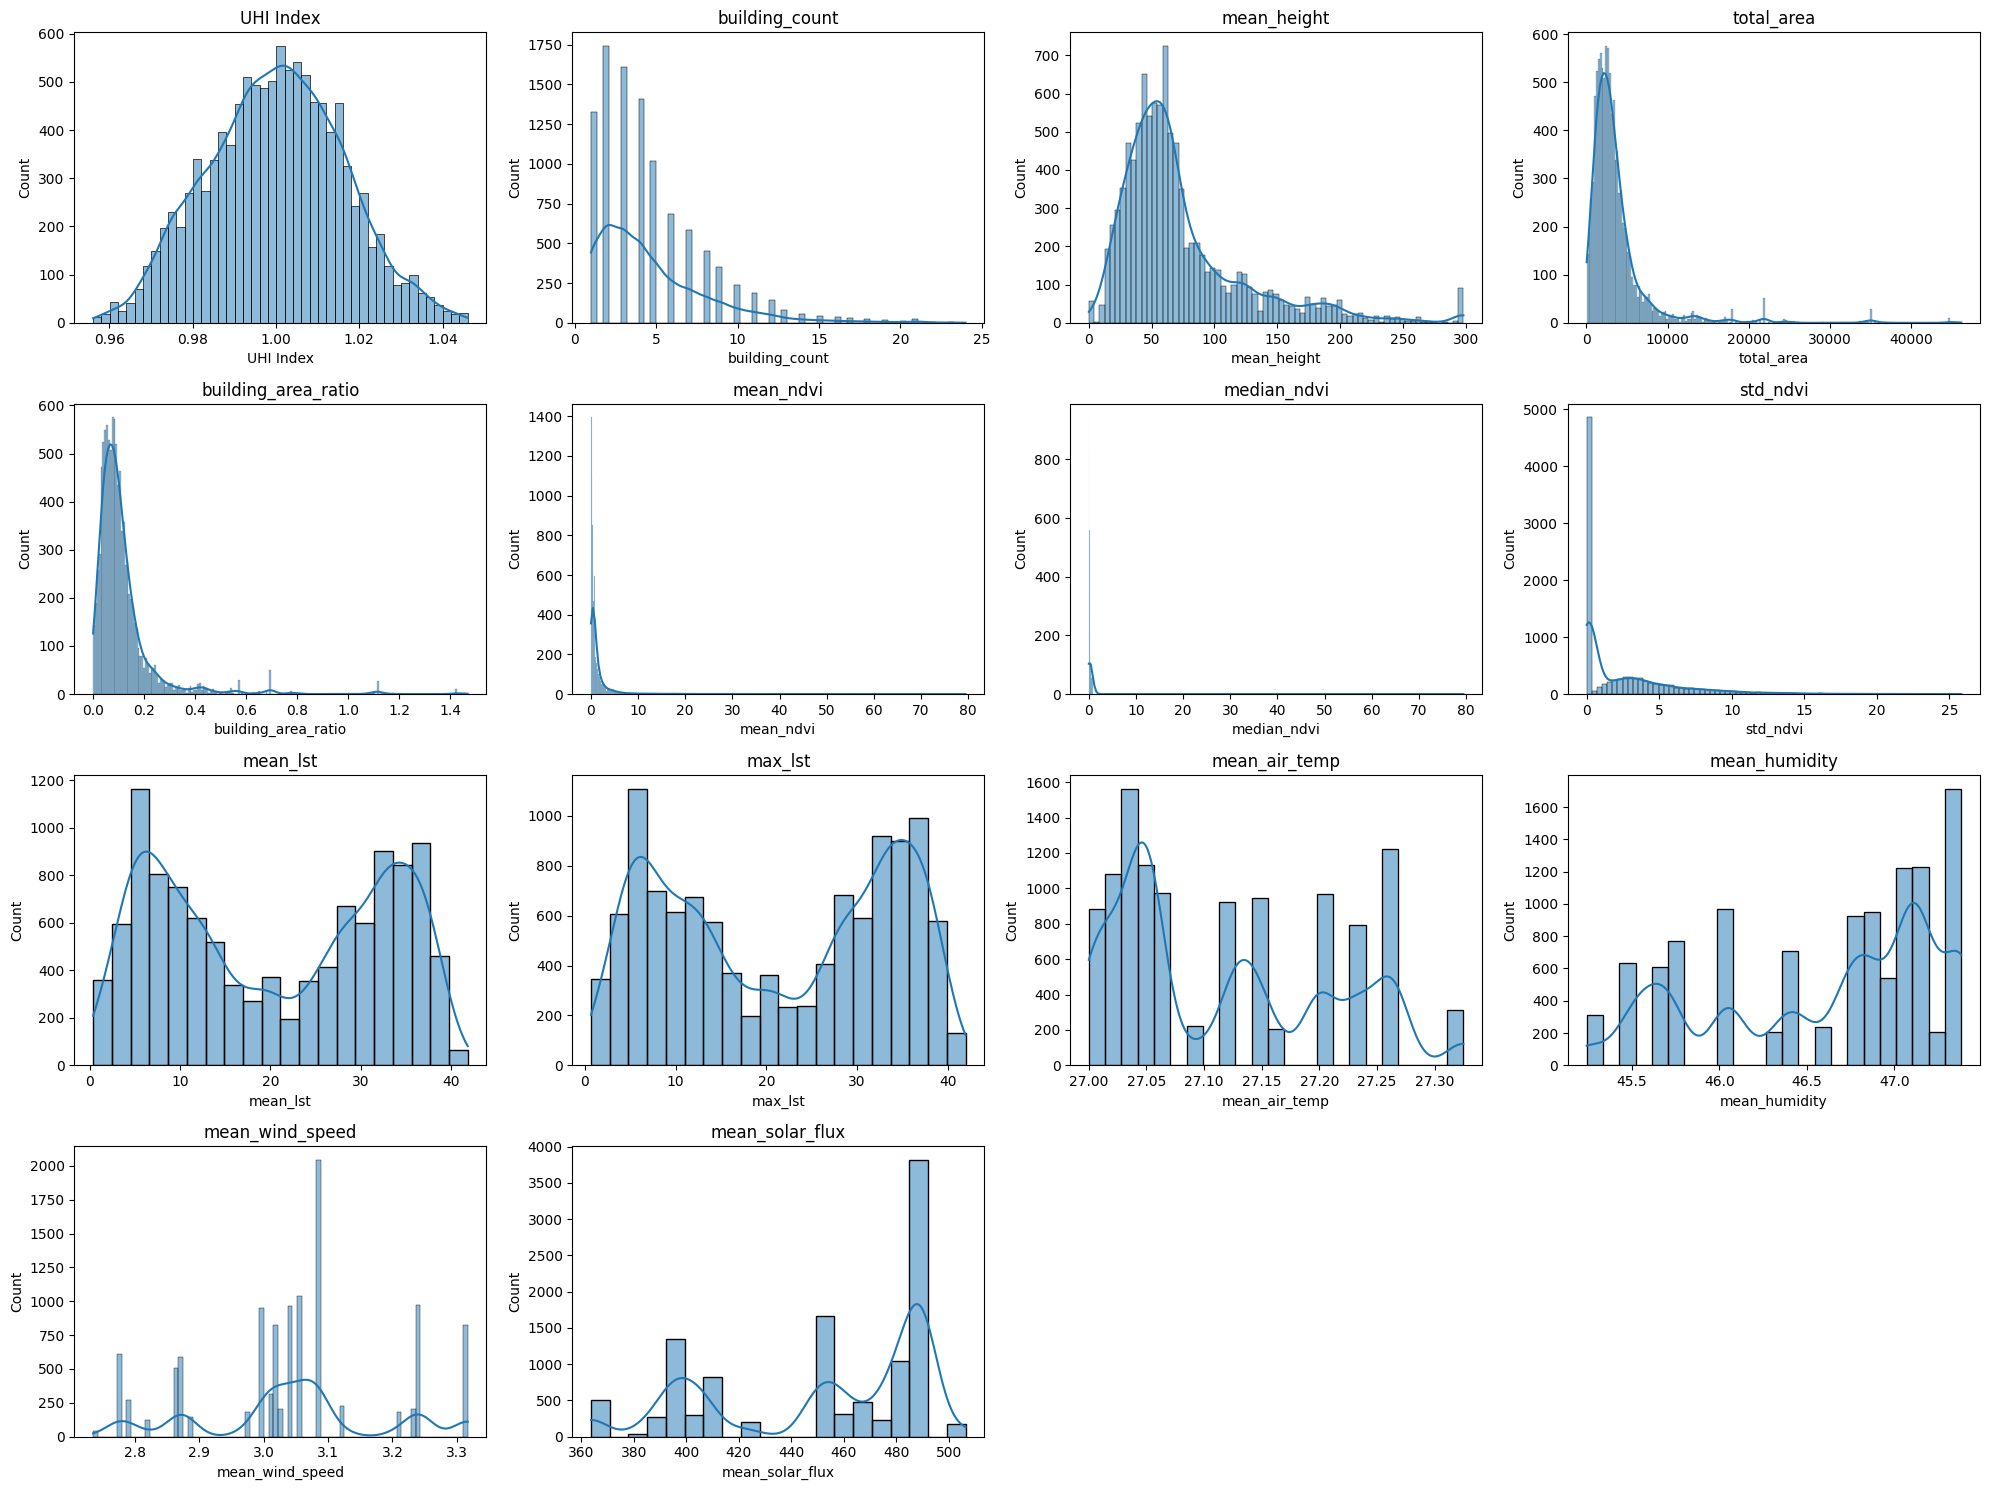

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

# List of key numeric columns to visualize (excluding the datetime column)
columns_to_plot = [
    'UHI Index', 'building_count', 'mean_height', 'total_area',
    'building_area_ratio', 'mean_ndvi', 'median_ndvi', 'std_ndvi',
    'mean_lst', 'max_lst', 'mean_air_temp', 'mean_humidity',
    'mean_wind_speed', 'mean_solar_flux'
]

plt.figure(figsize=(20, 15))
for i, col in enumerate(columns_to_plot):
    plt.subplot(4, 4, i + 1)
    sns.histplot(df_model[col].dropna(), kde=True)
    plt.title(col)
plt.tight_layout()
plt.show()


Correlation with UHI Index:
UHI Index              1.000000
Latitude               0.446435
Longitude              0.380995
std_ndvi               0.179877
mean_ndvi              0.101501
max_lst                0.064941
mean_lst               0.063894
mean_air_temp          0.037728
median_ndvi            0.025980
mean_wind_speed        0.016952
mean_solar_flux       -0.005958
building_count        -0.013129
mean_humidity         -0.020755
building_area_ratio   -0.079857
total_area            -0.079857
mean_height           -0.320103
Name: UHI Index, dtype: float64


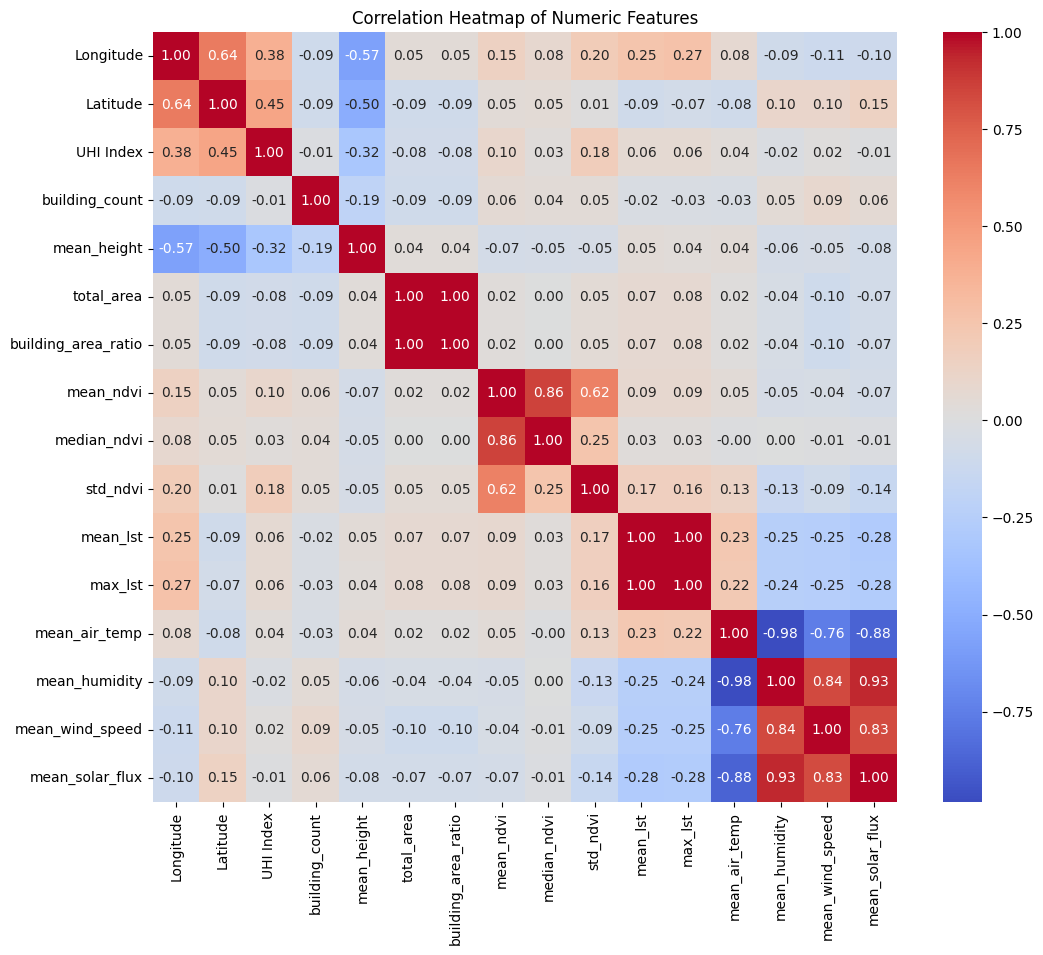

In [3]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Select only numeric columns (float or int)
numeric_cols = df_model.select_dtypes(include=['float64', 'int64']).columns

# Compute correlation matrix
corr_matrix = df_model[numeric_cols].corr()

# Display correlation with UHI Index specifically
print("Correlation with UHI Index:")
corr_with_uhi = corr_matrix["UHI Index"].sort_values(ascending=False)
print(corr_with_uhi)

# Plot a heatmap of the full correlation matrix
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap of Numeric Features")
plt.show()


In [4]:
# Impute missing building features with 0
df_model['building_count'] = df_model['building_count'].fillna(0)
df_model['mean_height'] = df_model['mean_height'].fillna(0)
df_model['total_area'] = df_model['total_area'].fillna(0)
df_model['building_area_ratio'] = df_model['building_area_ratio'].fillna(0)

# Impute missing NDVI values with the mean (citywide average)
ndvi_cols = ['mean_ndvi', 'median_ndvi', 'std_ndvi']
for col in ndvi_cols:
    df_model[col] = df_model[col].fillna(df_model[col].mean())

In [5]:
df_model.info()
df_model.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11229 entries, 0 to 11228
Data columns (total 17 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   Longitude            11229 non-null  float64       
 1   Latitude             11229 non-null  float64       
 2   datetime             11229 non-null  datetime64[ns]
 3   UHI Index            11229 non-null  float64       
 4   building_count       11229 non-null  float64       
 5   mean_height          11229 non-null  float64       
 6   total_area           11229 non-null  float64       
 7   building_area_ratio  11229 non-null  float64       
 8   mean_ndvi            11229 non-null  float64       
 9   median_ndvi          11229 non-null  float64       
 10  std_ndvi             11229 non-null  float64       
 11  mean_lst             11229 non-null  float64       
 12  max_lst              11229 non-null  float64       
 13  mean_air_temp        11229 non-

,Longitude,Latitude,datetime,UHI Index,building_count,mean_height,total_area,building_area_ratio,mean_ndvi,median_ndvi,std_ndvi,mean_lst,max_lst,mean_air_temp,mean_humidity,mean_wind_speed,mean_solar_flux
count,11229.000000,11229.000000,11229,11229.000000,11229.000000,11229.000000,11229.000000,11229.000000,11229.000000,11229.000000,11229.000000,11229.000000,11229.000000,11229.000000,11229.000000,11229.000000,11229.000000
mean,-73.933927,40.808800,2021-07-24 15:34:29.056906240,1.000001,4.162437,65.837665,3300.239649,0.105050,1.488524,0.657504,2.528013,20.383285,21.303275,27.115505,46.612558,3.045977,451.496339
min,-73.994457,40.758792,2021-07-24 15:01:00,0.956122,0.000000,0.000000,0.000000,0.000000,0.010654,0.010281,0.000000,0.387569,0.662418,27.000000,45.241667,2.735714,363.750000
25%,-73.955703,40.790905,2021-07-24 15:22:00,0.988577,2.000000,33.402000,1298.267634,0.041325,0.268988,0.092531,0.151100,8.343979,9.050239,27.041667,46.058333,3.000000,406.916667
50%,-73.932968,40.810688,2021-07-24 15:36:00,1.000237,3.000000,55.161429,2482.144642,0.079009,0.680560,0.166752,2.038940,19.991517,21.693495,27.058333,46.841667,3.042857,467.142857
75%,-73.909647,40.824515,2021-07-24 15:48:00,1.011176,6.000000,81.302565,3891.202755,0.123861,1.488524,0.544484,3.393039,32.419535,33.338690,27.200000,47.116667,3.083333,488.583333
max,-73.879458,40.859497,2021-07-24 15:59:00,1.046036,24.000000,298.129724,46164.591288,1.469461,79.466019,79.466019,25.821361,41.853466,41.962354,27.325000,47.383333,3.316667,506.357143
std,0.028253,0.023171,NaN,0.016238,3.530009,53.627346,4056.920193,0.129135,3.282333,3.277407,3.179090,12.289758,12.442727,0.093900,0.651460,0.142640,41.282787


In [9]:
# Clip NDVI columns to [–1, 1]
df_model['mean_ndvi'] = df_model['mean_ndvi'].clip(-1, 1)
df_model['median_ndvi'] = df_model['median_ndvi'].clip(-1, 1)
df_model['std_ndvi'] = df_model['std_ndvi'].clip(0, None) 

In [7]:
import numpy as np

# Avoid log(0) by adding a small constant if values can be 0
df_model['log_total_area'] = np.log1p(df_model['total_area'])  
df_model['log_building_area_ratio'] = np.log1p(df_model['building_area_ratio'])


In [10]:
print(df_model[['mean_ndvi', 'median_ndvi', 'std_ndvi', 'mean_lst', 'max_lst', 
                'total_area', 'building_area_ratio', 
                'log_total_area', 'log_building_area_ratio', 'mean_height']].describe())

          mean_ndvi   median_ndvi      std_ndvi      mean_lst       max_lst  \
count  11229.000000  11229.000000  11229.000000  11229.000000  11229.000000   
mean       0.631302      0.292613      2.528013     20.383285     21.303275   
std        0.356301      0.255705      3.179090     12.289758     12.442727   
min        0.010654      0.010281      0.000000      0.387569      0.662418   
25%        0.268988      0.092531      0.151100      8.343979      9.050239   
50%        0.680560      0.166752      2.038940     19.991517     21.693495   
75%        1.000000      0.544484      3.393039     32.419535     33.338690   
max        1.000000      1.000000     25.821361     41.853466     41.962354   

         total_area  building_area_ratio  log_total_area  \
count  11229.000000         11229.000000    11229.000000   
mean    3300.239649             0.105050        7.052685   
std     4056.920193             0.129135        2.518945   
min        0.000000             0.000000        

In [12]:
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import r2_score
import lightgbm as lgb

# Assuming df_model is already in memory in your notebook.
# Define features by excluding non-predictor columns
features = [col for col in df_model.columns if col not in ['UHI Index', 'datetime', 'Longitude', 'Latitude']]
X = df_model[features]
y = df_model['UHI Index']

# Split data into training and testing sets (70/30 split)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Set up a LightGBM regressor with a grid of hyperparameters for tuning
lgb_reg = lgb.LGBMRegressor(random_state=42)
param_grid = {
    'num_leaves': [31, 50],
    'learning_rate': [0.05, 0.1],
    'n_estimators': [100, 200]
}

# Use GridSearchCV with 5-fold cross-validation using R² as the scoring metric
grid = GridSearchCV(lgb_reg, param_grid, cv=5, scoring='r2', n_jobs=-1)
grid.fit(X_train, y_train)

# Output the best parameters and best cross-validation R² score
print("Best Parameters:", grid.best_params_)
print("Best CV R²:", grid.best_score_)

# Evaluate on the test set
y_pred = grid.predict(X_test)
test_r2 = r2_score(y_test, y_pred)
print("Test R²:", test_r2)


C:\Users\ADMIN\AppData\Roaming\Python\Python312\site-packages\dask\dataframe\__init__.py:42: FutureWarning: 
Dask dataframe query planning is disabled because dask-expr is not installed.

You can install it with `pip install dask[dataframe]` or `conda install dask`.
This will raise in a future version.

  warnings.warn(msg, FutureWarning)


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000333 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2666
[LightGBM] [Info] Number of data points in the train set: 7860, number of used features: 15
[LightGBM] [Info] Start training from score 1.000083
Best Parameters: {'learning_rate': 0.1, 'n_estimators': 200, 'num_leaves': 50}
Best CV R²: 0.8531685468076132
Test R²: 0.8640161624517123
